<a href="https://colab.research.google.com/github/ASaragga/GRF/blob/main/Notebook1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [86]:
using Pkg
Pkg.add(url="https://github.com/ASaragga/Caramel.jl")

    Updating git-repo `https://github.com/ASaragga/Caramel.jl`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
Precompiling packages...
           ✗ GLMakie
  0 dependencies successfully precompiled in 11 seconds. 456 already precompiled.
  1 dependency errored.
  For a report of the errors see `julia> err`. To retry use `pkg> precompile`


In [89]:
using Caramel, Plots

Obtemos dados de cotações da Apple do website Yahoo Finance

In [85]:
apple = AssetPrice("AAPL", Date(2020,10,01), Date(2025,03,15)) |> DataFrame
show(apple)

1118×3 DataFrame
  Row │ ticker  date        adjclose
      │ String  Date        Float64
──────┼──────────────────────────────
    1 │ AAPL    2020-10-01   113.882
    2 │ AAPL    2020-10-02   110.206
    3 │ AAPL    2020-10-05   113.599
    4 │ AAPL    2020-10-06   110.342
    5 │ AAPL    2020-10-07   112.214
    6 │ AAPL    2020-10-08   112.107
    7 │ AAPL    2020-10-09   114.057
    8 │ AAPL    2020-10-12   121.302
    9 │ AAPL    2020-10-13   118.084
   10 │ AAPL    2020-10-14   118.172
   11 │ AAPL    2020-10-15   117.704
  ⋮   │   ⋮         ⋮          ⋮
 1109 │ AAPL    2025-03-03   238.03
 1110 │ AAPL    2025-03-04   235.93
 1111 │ AAPL    2025-03-05   235.74
 1112 │ AAPL    2025-03-06   235.33
 1113 │ AAPL    2025-03-07   239.07
 1114 │ AAPL    2025-03-10   227.48
 1115 │ AAPL    2025-03-11   220.84
 1116 │ AAPL    2025-03-12   216.98
 1117 │ AAPL    2025-03-13   209.68
 1118 │ AAPL    2025-03-14   213.49
                    1097 rows omitted

In [100]:
# Selecionamos todas as linhas (:) mas apenas a coluna :adjclose.
prices = apple[:,:adjclose];
# O ponto e virgula no final, faz com que o resultado do comando não seja impresso.

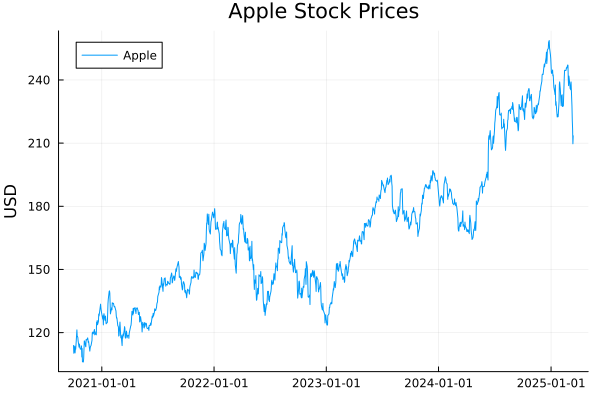

In [96]:
Plots.plot(apple[:,:date], prices, title="Apple Stock Prices",label="Apple", ylabel="USD")


In [101]:
# Calculamos retornos logarítmicos r = ln(Pt/Pt-1)
retornos = LogReturn("AAPL", Date(2020,10,01),Date(2025,01,01)) |> DataFrame
show(retornos)

1068×5 DataFrame
  Row │ ticker  date        interval  type    r
      │ String  Date        String    String  Float64
──────┼─────────────────────────────────────────────────
    1 │ AAPL    2020-10-02  1d        log     -0.032813
    2 │ AAPL    2020-10-05  1d        log      0.030327
    3 │ AAPL    2020-10-06  1d        log     -0.029088
    4 │ AAPL    2020-10-07  1d        log      0.016825
    5 │ AAPL    2020-10-08  1d        log     -0.000956
    6 │ AAPL    2020-10-09  1d        log      0.017246
    7 │ AAPL    2020-10-12  1d        log      0.061584
    8 │ AAPL    2020-10-13  1d        log     -0.026885
    9 │ AAPL    2020-10-14  1d        log      0.000743
   10 │ AAPL    2020-10-15  1d        log     -0.003969
   11 │ AAPL    2020-10-16  1d        log     -0.014099
  ⋮   │   ⋮         ⋮          ⋮        ⋮         ⋮
 1059 │ AAPL    2024-12-17  1d        log      0.009673
 1060 │ AAPL    2024-12-18  1d        log     -0.021655
 1061 │ AAPL    2024-12-19  1d        log   

In [103]:
# Selecionamos todas as linhas novamente (:) mas apenas a coluna :r.
r = retornos[:,:r]

1068-element Vector{Float64}:
 -0.032813
  0.030327
 -0.029088
  0.016825
 -0.000956
  0.017246
  0.061584
 -0.026885
  0.000743
 -0.003969
 -0.014099
 -0.025874
  0.013106
  ⋮
  0.000685
  0.011659
  0.009673
 -0.021655
  0.00699
  0.018641
  0.00306
  0.011413
  0.003171
 -0.013331
 -0.013352
 -0.007083